# Module 7 Chapter Exercises

## Ryan Waterman

## 8/23/2025

In [83]:
from ISLP import load_data, confusion_table
from sklearn.ensemble import GradientBoostingRegressor as GBR
import sklearn.model_selection as skm
from ISLP.models import ModelSpec as MS
import numpy as np
from matplotlib.pyplot import subplots
from sklearn.tree import (DecisionTreeClassifier as DTC,
DecisionTreeRegressor as DTR,
plot_tree,
export_text)
from sklearn.metrics import (accuracy_score,
log_loss)

## Chapter 8 Lab 8.3.4: Boosting

Here we use GradientBoostingRegressor() from sklearn.ensemble to fit boosted regression trees to the Boston data set. For classification we would use GradientBoostingClassifier(). The argument n_estimators=5000 indicates that we want 5000 trees, and the option max_depth=3 limits the depth of each tree. The argument learning_rate is the λ mentioned earlier in the description of boosting.

In [84]:
# Load data
Boston = load_data("Boston")

# Create transform
model = MS(Boston.columns.drop('medv'), intercept=False)
D = model.fit_transform(Boston) 
feature_names = list(D.columns)
X = np.asarray(D)

(X_train,
X_test,
y_train,
y_test) = skm.train_test_split(X,
                                Boston['medv'],
                                test_size=0.3,
                                random_state=0)

In [85]:
boost_boston = GBR(n_estimators=5000,
                    learning_rate=0.001,
                    max_depth=3,
                    random_state=0)

boost_boston.fit(X_train, y_train)

,loss,'squared_error'
,learning_rate,0.001
,n_estimators,5000
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


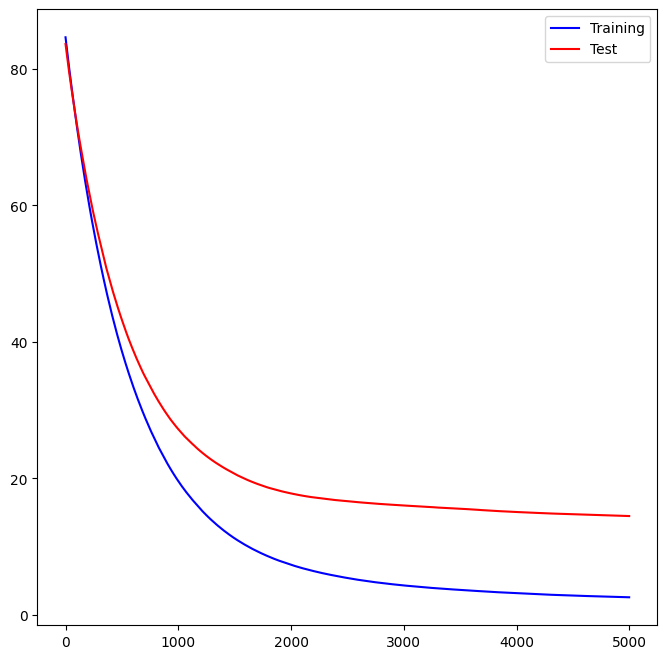

In [86]:
test_error = np.zeros_like(boost_boston.train_score_)

for idx, y_ in enumerate(boost_boston.staged_predict(X_test)):
    test_error[idx] = np.mean((y_test - y_)**2)

plot_idx = np.arange(boost_boston.train_score_.shape[0])
ax = subplots(figsize=(8,8))[1]

ax.plot(plot_idx,
    boost_boston.train_score_,
    'b',
    label='Training')

ax.plot(plot_idx,
    test_error,
    'r',
    label='Test')

ax.legend();

In [87]:
y_hat_boost = boost_boston.predict(X_test);
np.mean((y_test - y_hat_boost)**2)

np.float64(14.481405918831591)

In [88]:
boost_boston = GBR(n_estimators=5000,
                    learning_rate=0.2,
                    max_depth=3,
                    random_state=0)

boost_boston.fit(X_train,
                y_train)

y_hat_boost = boost_boston.predict(X_test);

np.mean((y_test - y_hat_boost)**2)

np.float64(14.501514553719565)

## Chapter 8 Lab 8.3.5

In this section we demonstrate a Python implementation of BART found in the ISLP.bart package. We fit a model to the Boston housing data set. This BART() estimator is designed for quantitative outcome variables, though other implementations are available for fitting logistic and probit models to categorical outcomes.

In [89]:
from ISLP.bart import BART
import pandas as pd

In [90]:
(X_train,
X_test,
y_train,
y_test) = skm.train_test_split(X,
                                Boston['medv'],
                                test_size=0.3,
                                random_state=0)

In [91]:
bart_boston = BART(random_state=0, burnin=5, ndraw=15)
bart_boston.fit(X_train, y_train)

,num_trees,200
,num_particles,10
,max_stages,5000
,split_prob,<function BAR...0024081747BA0>
,min_depth,0
,std_scale,2
,split_prior,None
,ndraw,15
,burnin,5
,sigma_prior,"(5, ...)"
,num_quantile,50


In [92]:
yhat_test = bart_boston.predict(X_test.astype(np.float32))
np.mean((y_test - yhat_test)**2)

np.float64(22.145009458109232)

In [93]:
var_inclusion = pd.Series(bart_boston.variable_inclusion_.mean(0),
index=D.columns)
var_inclusion

crim       26.933333
zn         27.866667
indus      26.466667
chas       22.466667
nox        26.600000
rm         29.800000
age        22.733333
dis        26.466667
rad        23.666667
tax        24.133333
ptratio    24.266667
lstat      31.000000
dtype: float64

# Chapter Exercises: Problem 9 Parts G-K

## OJ Data Set Description

Purchase: A factor with levels ‘CH’ and ‘MM’ indicating whether the customer purchased Citrus Hill or Minute Maid Orange Juice

WeekofPurchase: Week of purchase

StoreID: Store ID

PriceCH: Price charged for CH

PriceMM: Price charged for MM

DiscCH: Discount offered for CH

DiscMM: Discount offered for MM

SpecialCH: Indicator of special on CH

SpecialMM: Indicator of special on MM

LoyalCH: Customer brand loyalty for CH

SalePriceMM: Sale price for MM

SalePriceCH: Sale price for CH

PriceDiff: Sale price of MM less sale price of CH

Store7: A factor with levels ‘No’ and ‘Yes’ indicating whether the sale is at Store 7

PctDiscMM: Percentage discount for MM

PctDiscCH: Percentage discount for CH

ListPriceDiff: List price of MM less list price of CH

STORE: Which of 5 possible stores the sale occured at

## Part G

Produce a plot with tree size on the x-axis and cross-validated classification error rate on the y-axis.

In [94]:
oj = load_data('OJ')

In [95]:
from random import randint, seed

In [96]:
def split_data(data, train_count):
    seed(42)
    data_indices = list(data.index.values)
    train_indices = []

    for i in range(train_count):
        rand_idx = randint(1,len(data_indices))
        train_indices.append(data_indices[rand_idx])
        data_indices.remove(data_indices[rand_idx])

    training_data = data.iloc[train_indices]
    test_data = data.iloc[data_indices]
    
    return training_data, test_data

In [97]:
training_data, test_data = split_data(oj, 800) 

print(len(training_data), len(test_data))

800 270


In [98]:
model = MS(training_data.columns.drop('Purchase'), intercept=False)
D = model.fit_transform(training_data) 
feature_names = list(D.columns)
X_train = np.asarray(D)
Y_train = training_data['Purchase']

In [99]:
model = MS(test_data.columns.drop('Purchase'), intercept=False)
D = model.fit_transform(test_data) 
feature_names = list(D.columns)
X_test = np.asarray(D)
Y_test = test_data['Purchase']

In [100]:
from matplotlib.ticker import MaxNLocator

(array([3]),) 0.18518518518518517


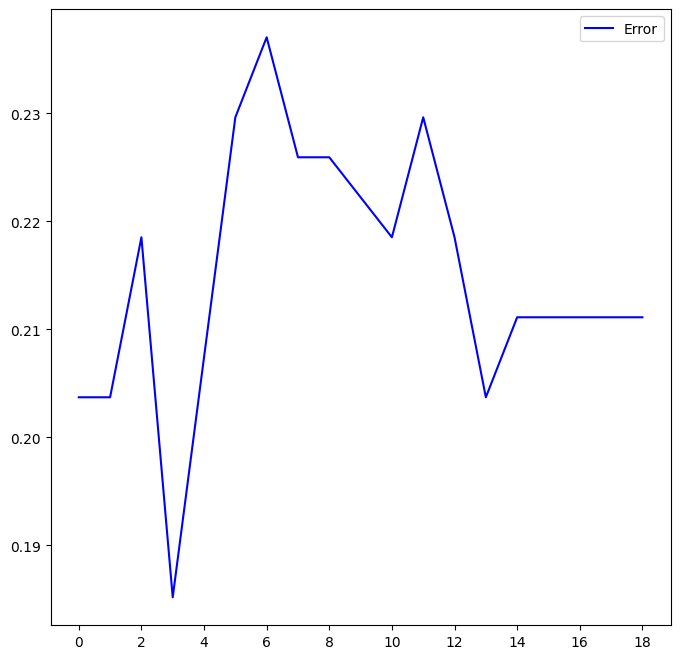

In [101]:
depth_min = 1
depth_max = 20

test_error = np.zeros(depth_max-depth_min)

for i in range(depth_min,depth_max):

    clf = DTC(criterion='entropy',
            max_depth=i,
            random_state=0)
    
    clf.fit(X_train, Y_train)

    y_pred = clf.predict(X_test)

    comparison = (y_pred != Y_test)

    error_rate = np.sum(comparison)/len(comparison)

    test_error[i-depth_min] = error_rate

print(np.where(test_error==min(test_error)), min(test_error))

tree_size = np.arange(depth_max-depth_min)

ax = subplots(figsize=(8,8))[1]

ax.xaxis.set_major_locator(MaxNLocator(integer=True))

ax.plot(tree_size,
    test_error,
    'b',
    label='Error')

ax.legend();

**The test error is very erratic depending on the tree size, but plateaus at a size of 14. The minimum error achieved was with a tree size of 3, with an error rate of 0.185.**

## Part H

Which tree size corresponds to the lowest cross-validated classification error rate?

**The tree size with the lowest cross-validation classification error rate is 3, producing an error rate of 0.185.**

## Part I

Produce a pruned tree corresponding to the optimal tree size obtained using cross-validation. If cross-validation does not lead to selection of a pruned tree, then create a pruned tree with five terminal nodes.

In [102]:
optimal_size_dtc = DTC(criterion='entropy',
                        max_depth=3,
                        random_state=0)

optimal_size_dtc.fit(X_train, Y_train)

ccp_path = optimal_size_dtc.cost_complexity_pruning_path(X_train, Y_train)
ccp_alphas, impurities = ccp_path.ccp_alphas, ccp_path.impurities

print(len(ccp_alphas))

8


[0.01968689 0.02434193 0.03238818 0.04945144] 0.2037037037037037


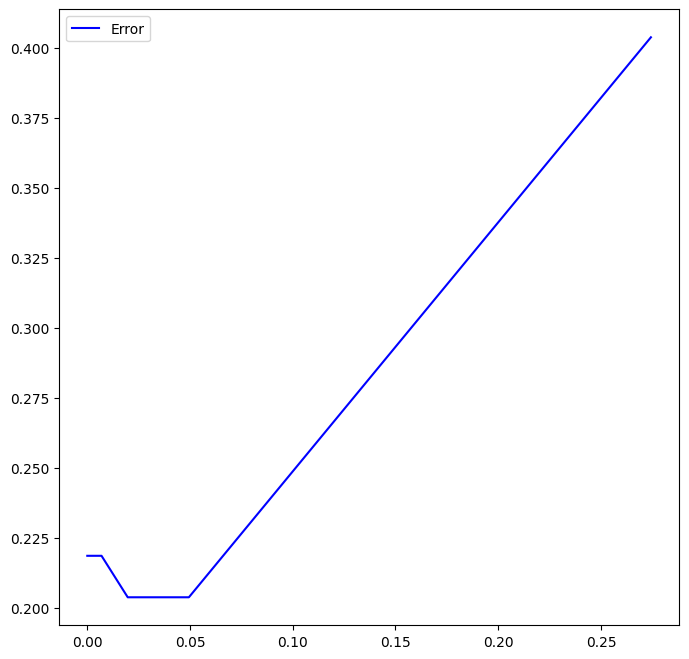

In [103]:
test_error = np.zeros(len(ccp_alphas))

for i, alpha in enumerate(ccp_alphas):

    clf = DTC(criterion='entropy',
            max_depth=3,
            random_state=0,
            ccp_alpha=alpha)
    
    clf.fit(X_train, Y_train)

    y_pred = clf.predict(X_test)

    comparison = (y_pred != Y_test)

    error_rate = np.sum(comparison)/len(comparison)

    test_error[i] = error_rate

print(ccp_alphas[np.where(test_error==min(test_error))], min(test_error))

ax = subplots(figsize=(8,8))[1]

ax.plot(ccp_alphas,
    test_error,
    'b',
    label='Error')

ax.legend();

In [104]:
pruned_optimal_dtc = DTC(criterion='entropy',
                        max_depth=3,
                        random_state=0,
                        ccp_alpha=0.02434193)

pruned_optimal_dtc.fit(X_train, Y_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


**The test error reaches a minimum of 0.2037 when alpha is in the range 0.01968689 to 0.04945144, then linearly increases with an increase in alpha. The alpha selected for the pruned model was 0.02434193.**

## Part J 

Compare the training error rates between the pruned and unpruned trees. Which is higher?

In [105]:
def compute_error_rate(model, X, Y):
    y_pred = model.predict(X)
    comparison = (y_pred != Y)
    return np.sum(comparison)/len(comparison)

In [106]:
pruned_error = compute_error_rate(pruned_optimal_dtc, X_train, Y_train)
unpruned_error = compute_error_rate(optimal_size_dtc, X_train, Y_train)

print(f'Un-pruned model train error rate: {unpruned_error}\tPruned model train error rate: {pruned_error}')

Un-pruned model train error rate: 0.1725	Pruned model train error rate: 0.18625


**The pruned model has a higher train error rate of 0.18625 as compared to 0.1725 for the unpruned model.**

## Part K

Compare the test error rates between the pruned and unpruned trees. Which is higher?

In [107]:
pruned_error = compute_error_rate(pruned_optimal_dtc, X_test, Y_test)
unpruned_error = compute_error_rate(optimal_size_dtc, X_test, Y_test)

print(f'Un-pruned model test error rate: {unpruned_error}\tPruned model test error rate: {pruned_error}')

Un-pruned model test error rate: 0.21851851851851853	Pruned model test error rate: 0.2037037037037037


**The un-pruned model has a higher test error rate of 0.2185 as compared to 0.2037 for the pruned model.**

# Problem 10

We now use boosting to predict Salary in the Hitters data set.

## Data Set Description

Major League Baseball Data from the 1986 and 1987 seasons.

AtBat: Number of times at bat in 1986

Hits: Number of hits in 1986

HmRun: Number of home runs in 1986

Runs: Number of runs in 1986

RBI: Number of runs batted in in 1986

Walks: Number of walks in 1986

Years: Number of years in the major leagues

CAtBat: Number of times at bat during his career

CHits: Number of hits during his career

CHmRun: Number of home runs during his career

CRuns: Number of runs during his career

CRBI: Number of runs batted in during his career

CWalks: Number of walks during his career

League: A factor with levels A and N indicating player’s league at the end of 1986

Division: A factor with levels E and W indicating player’s division at the end of 1986

PutOuts: Number of put outs in 1986

Assists: Number of assists in 1986

Errors: Number of errors in 1986

Salary: 1987 annual salary on opening day in thousands of dollars

NewLeague: A factor with levels A and N indicating player’s league at the beginning of 1987

## Part A

Remove the observations for whom the salary information is unknown, and then log-transform the salaries.

In [170]:
hitters = load_data('Hitters')

hitters.head(5)

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
0,293,66,1,30,29,14,1,293,66,1,30,29,14,A,E,446,33,20,NaN,A
1,315,81,7,24,38,39,14,3449,835,69,321,414,375,N,W,632,43,10,475.0,N
2,479,130,18,66,72,76,3,1624,457,63,224,266,263,A,W,880,82,14,480.0,A
3,496,141,20,65,78,37,11,5628,1575,225,828,838,354,N,E,200,11,3,500.0,N
4,321,87,10,39,42,30,2,396,101,12,48,46,33,N,E,805,40,4,91.5,N


In [171]:
hitters.dropna(subset=['Salary'], inplace=True, axis = 0)

hitters.head(5)

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
1,315,81,7,24,38,39,14,3449,835,69,321,414,375,N,W,632,43,10,475.0,N
2,479,130,18,66,72,76,3,1624,457,63,224,266,263,A,W,880,82,14,480.0,A
3,496,141,20,65,78,37,11,5628,1575,225,828,838,354,N,E,200,11,3,500.0,N
4,321,87,10,39,42,30,2,396,101,12,48,46,33,N,E,805,40,4,91.5,N
5,594,169,4,74,51,35,11,4408,1133,19,501,336,194,A,W,282,421,25,750.0,A


In [172]:
hitters.reset_index(inplace=True, drop=True)
hitters.head(5)

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
0,315,81,7,24,38,39,14,3449,835,69,321,414,375,N,W,632,43,10,475.0,N
1,479,130,18,66,72,76,3,1624,457,63,224,266,263,A,W,880,82,14,480.0,A
2,496,141,20,65,78,37,11,5628,1575,225,828,838,354,N,E,200,11,3,500.0,N
3,321,87,10,39,42,30,2,396,101,12,48,46,33,N,E,805,40,4,91.5,N
4,594,169,4,74,51,35,11,4408,1133,19,501,336,194,A,W,282,421,25,750.0,A


In [173]:
hitters['Salary'] = np.log(hitters['Salary'])
hitters.head(5)

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
0,315,81,7,24,38,39,14,3449,835,69,321,414,375,N,W,632,43,10,6.163315,N
1,479,130,18,66,72,76,3,1624,457,63,224,266,263,A,W,880,82,14,6.173786,A
2,496,141,20,65,78,37,11,5628,1575,225,828,838,354,N,E,200,11,3,6.214608,N
3,321,87,10,39,42,30,2,396,101,12,48,46,33,N,E,805,40,4,4.516339,N
4,594,169,4,74,51,35,11,4408,1133,19,501,336,194,A,W,282,421,25,6.620073,A


In [175]:
#Convert categorical to numeric
columns = set(hitters.columns)
numerical = set(hitters.describe().columns)

categorical = list(columns - numerical)

for col in categorical:
    hitters[col] = hitters[col].factorize()[0]

hitters.head(5)

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
0,315,81,7,24,38,39,14,3449,835,69,321,414,375,0,0,632,43,10,6.163315,0
1,479,130,18,66,72,76,3,1624,457,63,224,266,263,1,0,880,82,14,6.173786,1
2,496,141,20,65,78,37,11,5628,1575,225,828,838,354,0,1,200,11,3,6.214608,0
3,321,87,10,39,42,30,2,396,101,12,48,46,33,0,1,805,40,4,4.516339,0
4,594,169,4,74,51,35,11,4408,1133,19,501,336,194,1,0,282,421,25,6.620073,1


## Part B

Create a training set consisting of the first 200 observations, and a test set consisting of the remaining observations.

In [176]:
train_indices = [i for i in range(0,200)]
test_indices = [i for i in range(200,len(hitters))]

Y = hitters['Salary']
X = hitters.drop('Salary', axis = 1)

X_train, Y_train, X_test, Y_test = (
                                    X.iloc[train_indices],
                                    Y.iloc[train_indices],
                                    X.iloc[test_indices],
                                    Y.iloc[test_indices]
                                    )

print(len(X_train), len(Y_train), len(X_test), len(Y_test), len(hitters)-len(X_train))

print(X_train.iloc[[199]].values)

print(X_test.iloc[[0]].values)

200 200 63 63 63
[[ 608  160   28  130   74   89    8 4071 1182  103  862  417  708    1
     1  426    4    6    1]]
[[ 419  101   18   65   58   92   20 9528 2510  548 1509 1659 1342    1
     0    0    0    0    1]]


## Part C

Perform boosting on the training set with 1,000 trees for a range of values of the shrinkage parameter λ. Produce a plot with different shrinkage values on the x-axis and the corresponding training set MSE on the y-axis.

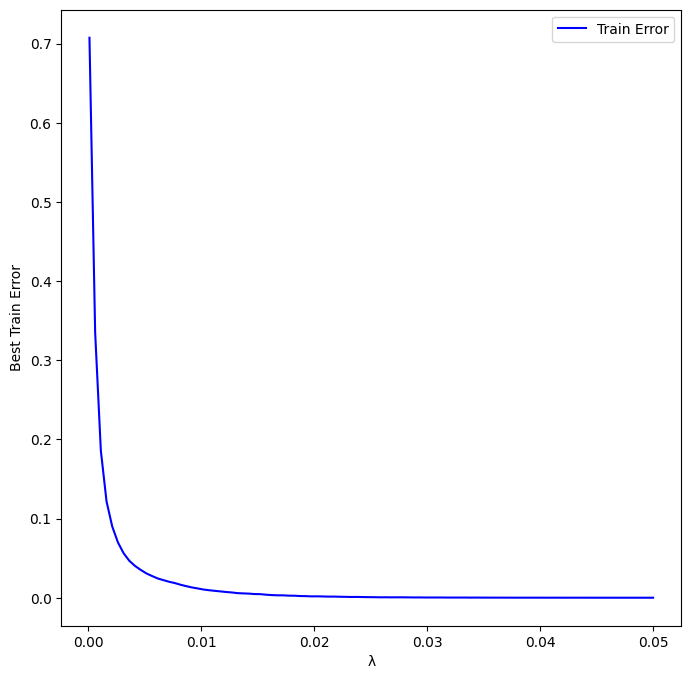

In [182]:
λ_range = np.linspace(0.0001, 0.05, 100)
train_error = []

for λ in list(λ_range):

    hitters_boosted = GBR(n_estimators=1000,
                        learning_rate=λ,
                        max_depth=3,
                        random_state=0)
    
    hitters_boosted.fit(X_train, Y_train)

    # Append the best train error
    train_error.append(np.min(hitters_boosted.train_score_))

ax = subplots(figsize=(8,8))[1]

ax.plot(λ_range,
        np.array(train_error),
        'b',
        label='Train Error')

ax.set_xlabel('λ')
ax.set_ylabel('Best Train Error')
ax.legend();

**The train MSE follows a smooth, exponentially decaying curve as λ increases. The curve appears to plateau at about λ=0.02.**

## Part D

Produce a plot with different shrinkage values on the x-axis and the corresponding test set MSE on the y-axis.

In [ ]:
λ_range = np.linspace(0.0001, 0.05, 100)
test_error = []

for λ in list(λ_range):

    hitters_boosted = GBR(n_estimators=1000,
                        learning_rate=λ,
                        max_depth=3,
                        random_state=0)
    
    hitters_boosted.fit(X_train, Y_train)

    Y_pred = hitters_boosted.predict(X_test)

    # Append the best train error
    test_error.append(np.mean((Y_test - Y_pred)**2))

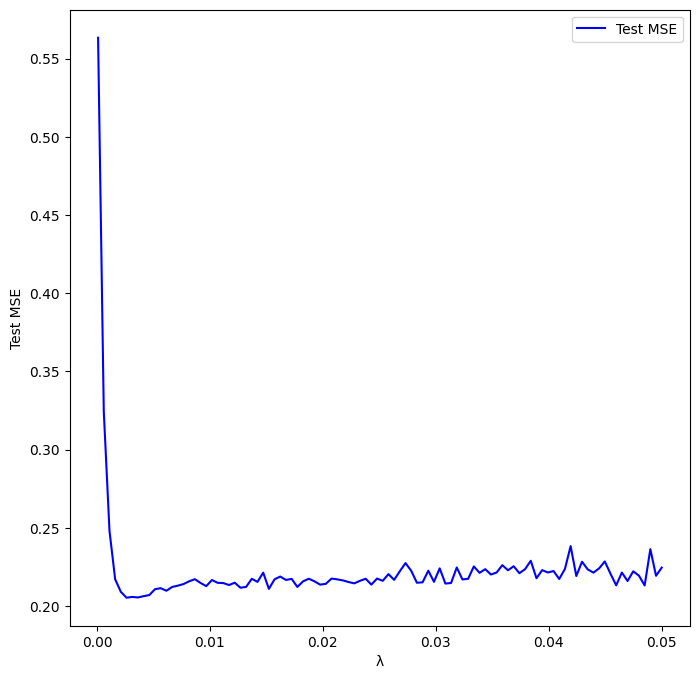

In [190]:
ax = subplots(figsize=(8,8))[1]

ax.plot(λ_range,
        np.array(test_error),
        'b',
        label='Test MSE')

ax.set_xlabel('λ')
ax.set_ylabel('Test MSE')
ax.legend();

**Interestingly, the test error vs λ curve is far more jagged than that of the train error vs λ curve. I suspect this is because of overfitting to the training data, which would cause 'random' increases and decreases in error across the test λ range due to outliers.**

## Part E

Compare the test MSE of boosting to the test MSE that results from applying two of the regression approaches seen in Chapters 3 and 6.

**Build an OLS model:**

In [189]:
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error

In [193]:
#Create an OLS model
ols = sm.OLS(endog=Y_train, exog=X_train).fit()
ols_test_y_pred = ols.predict(X_test)

ols_test_mse = mean_squared_error(y_true=Y_test, y_pred=ols_test_y_pred)
ols_test_mse

1.8281362777935029

**Build a Ridge Regression Model:**

In [201]:
import sklearn.linear_model as skl
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import warnings

warnings.filterwarnings('ignore')

In [202]:
Xs = X_train - np.array(X_train.mean(0))[None,:]
X_scale = X_train.std(0)
Xs = Xs / np.array(X_scale)[None,:]
lambdas = 10**np.linspace(8, -2, 100) / Y_train.std()

soln_array = skl.ElasticNet.path(Xs,
                                Y_train,
                                l1_ratio=0.,
                                alphas=lambdas)[1]

In [203]:
mse_scores = {}

for i, lam in enumerate(lambdas): 
    ridge = skl.ElasticNet(alpha=lam, l1_ratio=0)
    scaler = StandardScaler(with_mean=True, with_std=True)
    pipe = Pipeline(steps=[('scaler', scaler), ( 'ridge', ridge)]) 
    pipe.fit(X_train, Y_train)

    validation = skm.ShuffleSplit(n_splits=1,
                test_size=0.8,
                random_state=0)

    results = skm.cross_validate(ridge,
                                X_train,
                                Y_train,
                                scoring='neg_mean_squared_error',
                                cv=validation)
    
    mse_scores[-results['test_score'][0]] = i

print(f'Lowest MSE lambda: {lambdas[mse_scores[min(mse_scores.keys())]]}\nIndex: {mse_scores[min(mse_scores.keys())]}\nMSE: {min(mse_scores.keys())}')

Lowest MSE lambda: 9964.20081123458
Index: 40
MSE: 0.457896216857333


In [207]:
ridge = skl.ElasticNet(l1_ratio=0.,
                        alpha=lambdas[mse_scores[min(mse_scores.keys())]])
scaler = StandardScaler(with_mean=True, with_std=True)
pipe = Pipeline(steps=[('scaler', scaler), ( 'ridge', ridge)]) 
pipe.fit(X_train, Y_train)

ridge_test_pred = pipe.predict(X_test)

ridge_test_mse = mean_squared_error(y_true=Y_test, y_pred=ridge_test_pred)
ridge_test_mse

0.6471502044418119

In [208]:
print(min(test_error))

0.20534453684254936


**Now that the test MSE has been computed for each model, lets compare:**

1. **Boosted Test MSE: 0.205**
2. **OLS Test MSE: 1.828**
3. **Ridge Regression Test MSE: 0.647**

**The boosted model far outperforms both OLS and Ridge Regression, which is expected given the increase in complexity of the model, as well as the extensive tuning that went into it's creation. The OLS model, which does not feature any tuning, was far outperformed by the ridge regression model, for which alpha tuning was performed.**


## Part F

Which variables appear to be the most important predictors in the boosted model?

In [209]:
from ISLP.bart import BART

In [211]:
bart_hitters = BART(random_state=0, burnin=5, ndraw=15)
bart_hitters.fit(X_train, Y_train)

,num_trees,200
,num_particles,10
,max_stages,5000
,split_prob,<function BAR...0024081747BA0>
,min_depth,0
,std_scale,2
,split_prior,None
,ndraw,15
,burnin,5
,sigma_prior,"(5, ...)"
,num_quantile,50


In [212]:
yhat_test = bart_hitters.predict(X_test.astype(np.float32))
np.mean((Y_test - yhat_test)**2)

np.float64(0.2543434853842852)

In [220]:
var_inclusion = pd.Series(bart_hitters.variable_inclusion_.mean(0), index=X_train.columns)

most_important_vars = var_inclusion.sort_values()[-5::]

most_important_vars

CRuns     17.266667
CHmRun    17.333333
CWalks    18.000000
Years     18.600000
CRBI      19.000000
dtype: float64

**The 5 most important predictors for the hitters data set are 'CRuns', 'CHmRun', 'CWalks', 'Years', and 'CRBI'. This is an intuitive result, as the number of career runs, career home runs, career walks, years in the league, and career RBIs are all features of the talent level of the individual, which is directly proportional to the pay they would receive.**

## Part G

Now apply bagging to the training set. What is the test set MSE for this approach?

In [221]:
from sklearn.ensemble import RandomForestRegressor as RF

In [222]:
bag_hitters = RF(max_features=X_train.shape[1], random_state=0)
bag_hitters.fit(X_train, Y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,19
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


np.float64(0.2347836524190363)

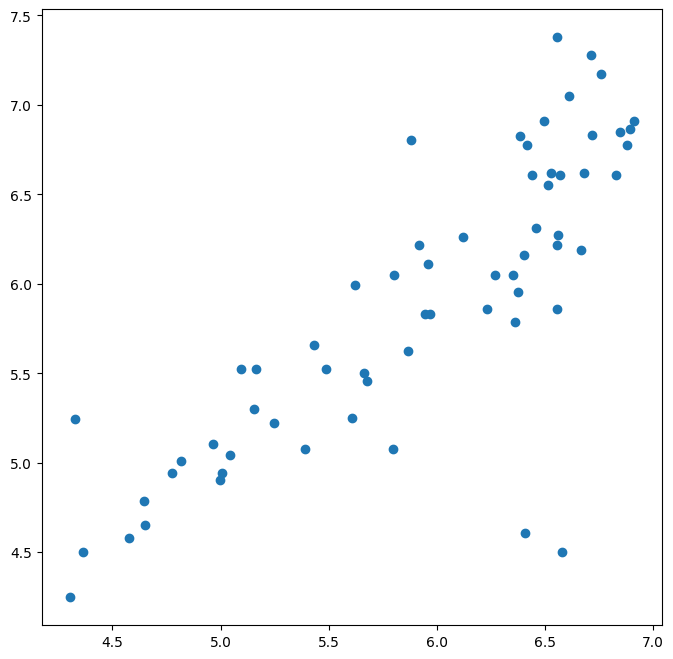

In [224]:
ax = subplots(figsize=(8,8))[1]

y_hat_bag = bag_hitters.predict(X_test)

ax.scatter(y_hat_bag, Y_test)

np.mean((Y_test - y_hat_bag)**2)

**The test MSE associated with the bagged regression tree is 0.235, which is similar to the boosted model. The implementation of the bagged model is far simpler than that of the boosted model due to the lack of tuning, but I imagine each model has their respective pros and cons given the application.**